<a href="https://colab.research.google.com/github/soham-2020/ARP-Network-Scanne/blob/main/EV_Charging_Peak_Load_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import numpy as np
import pandas as pd
dataset=pd.read_csv('/content/ev_charging_patterns.csv')
print(dataset.head(10))

   User ID Vehicle Model  Battery Capacity (kWh) Charging Station ID  \
0   User_1        BMW i3              108.463007         Station_391   
1   User_2  Hyundai Kona              100.000000         Station_428   
2   User_3    Chevy Bolt               75.000000         Station_181   
3   User_4  Hyundai Kona               50.000000         Station_327   
4   User_5  Hyundai Kona               50.000000         Station_108   
5   User_6   Nissan Leaf               50.000000         Station_335   
6   User_7    Chevy Bolt               85.000000         Station_162   
7   User_8    Chevy Bolt               75.000000         Station_302   
8   User_9    Chevy Bolt               62.000000         Station_493   
9  User_10  Hyundai Kona               50.000000         Station_452   

  Charging Station Location  Charging Start Time    Charging End Time  \
0                   Houston  2024-01-01 00:00:00  2024-01-01 00:39:00   
1             San Francisco  2024-01-01 01:00:00  2024-01-01 

In [45]:
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   User ID                                   1320 non-null   object 
 1   Vehicle Model                             1320 non-null   object 
 2   Battery Capacity (kWh)                    1320 non-null   float64
 3   Charging Station ID                       1320 non-null   object 
 4   Charging Station Location                 1320 non-null   object 
 5   Charging Start Time                       1320 non-null   object 
 6   Charging End Time                         1320 non-null   object 
 7   Energy Consumed (kWh)                     1254 non-null   float64
 8   Charging Duration (hours)                 1320 non-null   float64
 9   Charging Rate (kW)                        1254 non-null   float64
 10  Charging Cost (USD)                 

In [46]:
dataset.describe()


,Battery Capacity (kWh),Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years)
count,1320.000000,1254.000000,1320.000000,1254.000000,1320.000000,1320.000000,1320.000000,1254.000000,1320.000000,1320.000000
mean,74.534692,42.642894,2.269377,25.963003,22.551352,49.130012,75.141590,153.596788,15.263591,3.612843
std,20.626914,22.411705,1.061037,14.011326,10.751494,24.074134,17.080580,86.004987,14.831216,2.309824
min,1.532807,0.045772,0.095314,1.472549,0.234317,2.325959,7.604224,0.862361,-10.724770,0.000000
25%,62.000000,23.881193,1.397623,13.856583,13.368141,27.786903,62.053266,79.445335,2.800664,2.000000
50%,75.000000,42.691405,2.258136,25.603799,22.076360,48.241771,75.682496,152.259867,14.630846,4.000000
75%,85.000000,61.206218,3.112806,37.502998,31.646044,69.277921,88.201370,226.073284,27.981810,6.000000
max,193.003074,152.238758,7.635145,97.342255,69.407743,152.489761,177.708666,398.364775,73.169588,11.688592


In [47]:
peak_df = dataset[
    ["Energy Consumed (kWh)",
     "Charging Duration (hours)",
     "Charging Rate (kW)"]
]

In [48]:
peak_df = peak_df.dropna()

peak_df = peak_df[
    (peak_df["Charging Duration (hours)"] > 0) &
    (peak_df["Charging Rate (kW)"] > 0)
]


In [49]:
peak_df.head(10)

,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW)
0,60.712346,0.591363,36.389181
1,12.339275,3.133652,30.677735
2,19.128876,2.452653,27.513593
3,79.457824,1.266431,32.882870
4,19.629104,2.019765,10.215712
5,43.181137,1.167640,14.334523
6,36.862140,3.539619,26.185188
7,51.467617,2.655396,26.702908
8,43.592372,1.724204,14.294923
9,78.868607,2.026875,11.761000


In [50]:
peak_threshold = peak_df["Charging Rate (kW)"].quantile(0.90)
peak_sessions = peak_df[
    peak_df["Charging Rate (kW)"] >= peak_threshold
]
#We will find the top 10 percent highest power session

In [51]:
peak_threshold, peak_sessions.shape
# At this point, we know the peak charging rate is around ~45 kW
# and that roughly 120 sessions fall into the peak load category

(np.float64(44.995222235265096), (120, 3))

In [52]:

# Now we analyze what differentiates peak load sessions from normal ones
normal_sessions = peak_df[peak_df["Charging Rate (kW)"] < peak_threshold]


comparison = pd.DataFrame({
    "Normal Sessions": normal_sessions.mean(),
    "Peak Sessions": peak_sessions.mean()
})

comparison
# The comparison shows that peak load sessions are characterized primarily by significantly higher charging power.


,Normal Sessions,Peak Sessions
Energy Consumed (kWh),43.081177,41.166239
Charging Duration (hours),2.290222,2.294084
Charging Rate (kW),23.290605,48.870470


In [53]:
#We see how long the peak load last
peak_load_duration = peak_sessions["Charging Duration (hours)"].describe()
peak_load_duration
#We saw that the peak or high power charging on an average last 2.3 hours

,Charging Duration (hours)
count,120.000000
mean,2.294084
std,1.077251
min,0.530419
25%,1.339909
50%,2.361833
75%,3.213209
max,5.505496


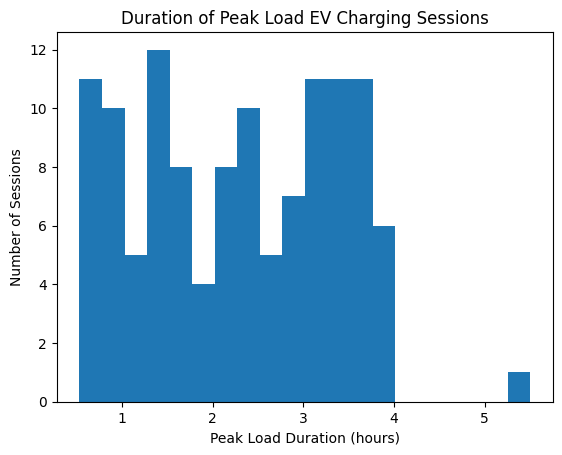

In [54]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(peak_sessions["Charging Duration (hours)"], bins=20)
plt.xlabel("Peak Load Duration (hours)")
plt.ylabel("Number of Sessions")
plt.title("Duration of Peak Load EV Charging Sessions")
plt.show()
# This histogram shows the duration spread of peak load charging sessions,it helps us anaylyze wether the  peak load events are short spikes or sustained over time


In [56]:
# Total energy across all valid charging sessions
total_energy_all = dataset[
    (dataset["Energy Consumed (kWh)"] > 1.0) &
    (dataset["Charging Duration (hours)"] > 0) &
    (dataset["Charging Rate (kW)"] > 0)
]["Energy Consumed (kWh)"].sum()

# Energy consumed by peak-load sessions only
peak_energy = peak_sessions["Energy Consumed (kWh)"].sum()

energy_pct = (peak_energy / total_energy_all) * 100
print(f"The top 10% of high-power charging sessions account for {energy_pct:.1f}% of total EV charging energy.")


BUSINESS INSIGHT:
The top 10% of high-power charging sessions account for 9.7% of total EV charging energy.


In [58]:
# Hypothetical grid stress index
dataset["Grid_Stress_Index"] = dataset["Charging Rate (kW)"] ** 2

In [60]:
stress_df = dataset[
    (dataset["Energy Consumed (kWh)"] > 1.0) &
    (dataset["Charging Duration (hours)"] > 0) &
    (dataset["Charging Rate (kW)"] > 0)
].copy()

In [62]:
stress_df["is_peak"] = stress_df["Charging Rate (kW)"] >= peak_threshold


In [63]:
# Energy contribution
total_energy = stress_df["Energy Consumed (kWh)"].sum()
peak_energy = stress_df[stress_df["is_peak"]]["Energy Consumed (kWh)"].sum()
energy_pct = (peak_energy / total_energy) * 100

# Stress contribution
total_stress = stress_df["Grid_Stress_Index"].sum()
peak_stress = stress_df[stress_df["is_peak"]]["Grid_Stress_Index"].sum()
stress_pct = (peak_stress / total_stress) * 100

energy_pct, stress_pct


(np.float64(9.670819113905829), np.float64(28.130208489500074))

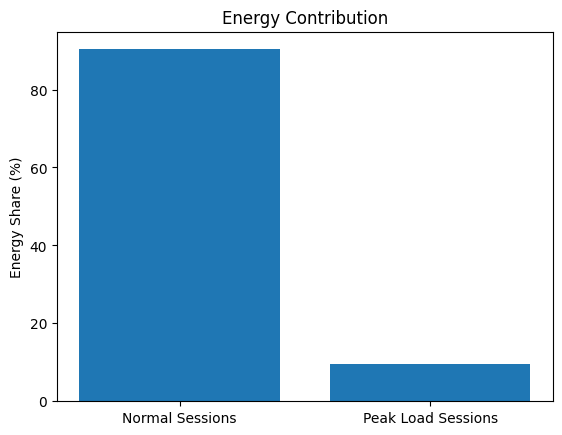

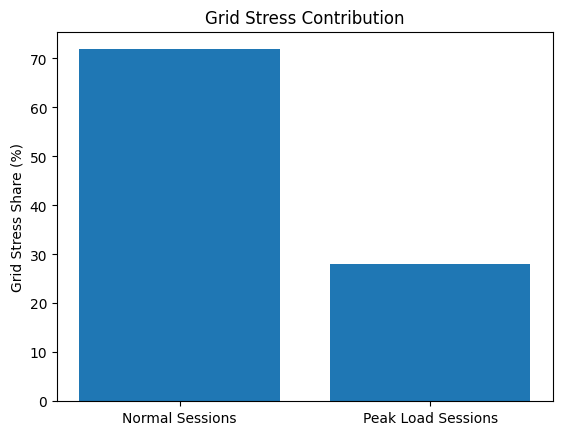

In [64]:
labels = ["Normal Sessions", "Peak Load Sessions"]

energy_values = [
    100 - energy_pct,
    energy_pct
]

stress_values = [
    100 - stress_pct,
    stress_pct
]

plt.figure()
plt.bar(labels, energy_values)
plt.ylabel("Energy Share (%)")
plt.title("Energy Contribution")
plt.show()
# Compare how total energy consumption is distributed
# between normal and peak load charging sessions


plt.figure()
plt.bar(labels, stress_values)
plt.ylabel("Grid Stress Share (%)")
plt.title("Grid Stress Contribution")
plt.show()
# Compare how grid stress is distributed between
# normal and peak load charging sessions